In [2]:
import pandas as pd

df = pd.read_csv(
    'predictions_results_tech_twitter_v2.csv',
    parse_dates=["forecast_start_date"],
)
df = df.sort_values("forecast_start_date").reset_index(drop=True)

df["price_change"] = df["btc_bybit_close_price"] - df["start_date_price"]
df["volatility_in_low_in_percent"] = abs(df["start_date_price"] - df["btc_bybit_low_price"]) / df["start_date_price"] * 100
df["volatility_in_high_in_percent"] = abs(df["start_date_price"] - df["btc_bybit_high_price"]) / df["start_date_price"] * 100

TEST_FRACTION = 0.20
n_test = max(int(round(len(df) * TEST_FRACTION)), 1)
TRAIN = df.iloc[:-n_test].copy()
TEST  = df.iloc[-n_test:].copy()

print("TRAIN:", TRAIN["forecast_start_date"].min().date(), "->",
                TRAIN["forecast_start_date"].max().date(), len(TRAIN))

print("TEST :", TEST["forecast_start_date"].min().date(), "->",
                TEST["forecast_start_date"].max().date(), len(TEST))


TRAIN: 2026-01-12 -> 2026-04-01 80
TEST : 2026-04-02 -> 2026-04-21 20


In [3]:
import os
print(os.listdir("."))


['.ipynb_checkpoints', 'predictions_results.csv', 'predictions_results_tech_twitter_v2.csv', 'RM_calc.ipynb']


In [4]:
TEST[["y_predict", "y_true", "price_change", "start_date_price", "volatility_in_low_in_percent", "volatility_in_high_in_percent"]].head(len(TEST))

,y_predict,y_true,price_change,start_date_price,volatility_in_low_in_percent,volatility_in_high_in_percent
80,SHORT,LONG,-1217.2,68120.3,3.549896,0.801083
81,SHORT,LONG,61.8,66903.2,0.928655,0.718800
82,LONG,LONG,335.7,66965.0,0.286866,0.895841
83,LONG,SHORT,1734.6,67300.7,1.033124,2.729392
84,LONG,LONG,-189.1,69035.3,1.050622,1.912210
85,LONG,SHORT,3081.2,68846.3,1.631315,5.721440
86,LONG,LONG,-854.8,71927.5,1.701992,1.312294
87,LONG,LONG,716.2,71072.7,0.880225,2.926581
88,LONG,LONG,1167.4,71788.0,0.494651,2.329219
89,LONG,SHORT,93.1,72955.4,0.599544,1.170167


In [14]:
import numpy as np
import pandas as pd

# ---------- ПАРАМЕТРЫ СТРАТЕГИИ ----------
FEE_PCT          = 0.001    # комиссия биржи за одну сторону сделки
SLIPPAGE_PCT     = 0.0001   # проскальзывание market-ордера при выходе

STOP_LOSS_PCT_LONG    = 3.0      # SL для LONG в %
TAKE_PROFIT_PCT_LONG  = 4.75     # TP для LONG в %

STOP_LOSS_PCT_SHORT   = 3.25     # SL для SHORT в %
TAKE_PROFIT_PCT_SHORT = 2.75     # TP для SHORT в %

# COMBINED:  LONG TP/SL = 4.75/3.0  |  SHORT TP/SL = 2.75/3.25

POS_SIZE_PCT     = 0.2     # доля депозита в одну сделку
CONF_THRESHOLD   = 1       # фильтр по |y_predict_confidence|

# ---------- НАЧАЛЬНОЕ СОСТОЯНИЕ ----------
budget       = 1000.0
equity_curve = [budget]
sl_hits, tp_hits, close_hits, skipped_double = 0, 0, 0, 0
total_fees, total_slip = 0.0, 0.0

# ---------- ОСНОВНОЙ ЦИКЛ ПО TEST ----------
trade_num = 0
for _, row in TEST.iterrows():
    y = row["y_predict"]
    if pd.isna(y) or y not in ("LONG", "SHORT"):
        continue

    conf = row["y_predict_confidence"]
    if pd.isna(conf) or abs(conf) >= 1.0 and abs(conf) <= 1.5:
        continue

    start  = row["start_date_price"]
    close  = row["btc_bybit_close_price"]
    vol_hi = row["volatility_in_high_in_percent"]
    vol_lo = row["volatility_in_low_in_percent"]

    if any(pd.isna(x) for x in (start, close, vol_hi, vol_lo)):
        continue

    notional = budget * POS_SIZE_PCT
    if notional <= 0:
        break

    entry_fee = notional * FEE_PCT

    # --- выбор TP/SL по стороне сделки ---
    if y == "LONG":
        sl_pct, tp_pct = STOP_LOSS_PCT_LONG,  TAKE_PROFIT_PCT_LONG
        sl_hit = vol_lo >= sl_pct
        tp_hit = vol_hi >= tp_pct
    else:  # SHORT
        sl_pct, tp_pct = STOP_LOSS_PCT_SHORT, TAKE_PROFIT_PCT_SHORT
        sl_hit = vol_hi >= sl_pct
        tp_hit = vol_lo >= tp_pct

    if sl_hit and tp_hit:
        skipped_double += 1
        date_str = row.get('forecast_start_date', '?')
        print(f"[SKIP double-hit] {date_str} {y} start={start:.2f} close={close:.2f} hi={vol_hi:.2f}% lo={vol_lo:.2f}%")
        continue
    elif sl_hit:
        pct = -sl_pct
    elif tp_hit:
        pct = tp_pct
    else:
        pct = (close / start - 1) * 100 if y == "LONG" else (1 - close / start) * 100

    exit_price_ratio = (1 + pct / 100) if y == "LONG" else (1 - pct / 100)

    if   sl_hit: sl_hits += 1;    exit_reason = "SL"
    elif tp_hit: tp_hits += 1;    exit_reason = "TP"
    else:        close_hits += 1; exit_reason = "CLOSE"

    pnl           = notional * (pct / 100)
    exit_notional = notional * exit_price_ratio
    exit_fee      = exit_notional * FEE_PCT
    slip          = notional * SLIPPAGE_PCT

    net_pnl       = pnl - entry_fee - exit_fee - slip
    budget_before = budget
    budget       += net_pnl
    total_fees   += entry_fee + exit_fee
    total_slip   += slip
    equity_curve.append(budget)

    trade_num += 1
    date_str  = row.get('forecast_start_date', '?')
    conf_val  = row['y_predict_confidence']
    print(
        f"#{trade_num:>3} {date_str} {y:<5} conf={conf_val:+.1f} | "
        f"start={start:>9.2f} close={close:>9.2f} hi=+{vol_hi:>5.2f}% lo=-{vol_lo:>5.2f}% | "
        f"exit={exit_reason:<5} TP={tp_pct:.2f}% SL={sl_pct:.2f}% | "
        f"notional=${notional:>8.2f} pnl=${pnl:+8.2f} fee=${entry_fee+exit_fee:>5.2f} slip=${slip:>5.2f} "
        f"budget: ${budget_before:>8.2f} -> ${budget:>8.2f}"
    )

print(f"\nИтого сделок: {trade_num} | TP={tp_hits} SL={sl_hits} CLOSE={close_hits} | пропущено double-hit: {skipped_double}")
print(f"Финальный депозит: ${budget:.2f} (начальный $1000)")
print(f"Суммарные комиссии: ${total_fees:.2f} | суммарный slippage: ${total_slip:.2f}")


#  1 2026-04-02 00:00:00 SHORT conf=-2.0 | start= 68120.30 close= 66903.10 hi=+ 0.80% lo=- 3.55% | exit=TP    TP=2.75% SL=3.25% | notional=$  200.00 pnl=$   +5.50 fee=$ 0.39 slip=$ 0.02 budget: $ 1000.00 -> $ 1005.09
#  2 2026-04-03 00:00:00 SHORT conf=-2.0 | start= 66903.20 close= 66965.00 hi=+ 0.72% lo=- 0.93% | exit=CLOSE TP=2.75% SL=3.25% | notional=$  201.02 pnl=$   -0.19 fee=$ 0.40 slip=$ 0.02 budget: $ 1005.09 -> $ 1004.48
#  3 2026-04-05 00:00:00 LONG  conf=+0.5 | start= 67300.70 close= 69035.30 hi=+ 2.73% lo=- 1.03% | exit=CLOSE TP=4.75% SL=3.00% | notional=$  200.90 pnl=$   +5.18 fee=$ 0.41 slip=$ 0.02 budget: $ 1004.48 -> $ 1009.23
#  4 2026-04-07 00:00:00 LONG  conf=+2.0 | start= 68846.30 close= 71927.50 hi=+ 5.72% lo=- 1.63% | exit=TP    TP=4.75% SL=3.00% | notional=$  201.85 pnl=$   +9.59 fee=$ 0.41 slip=$ 0.02 budget: $ 1009.23 -> $ 1018.38
#  5 2026-04-08 00:00:00 LONG  conf=+2.0 | start= 71927.50 close= 71072.70 hi=+ 1.31% lo=- 1.70% | exit=CLOSE TP=4.75% SL=3.00% | no

In [16]:
# double_hits = 0
# for _, row in TEST.iterrows():
#     y = row["y_predict"]
#     if y not in ("LONG", "SHORT"):
#         continue
#     vol_hi = row["volatility_in_high_in_percent"]
#     vol_lo = row["volatility_in_low_in_percent"]
#     if pd.isna(vol_hi) or pd.isna(vol_lo):
#         continue
#     if vol_hi >= TAKE_PROFIT_PCT and vol_lo >= STOP_LOSS_PCT:
#         double_hits += 1

# print(f"Дней с двойным попаданием: {double_hits}")

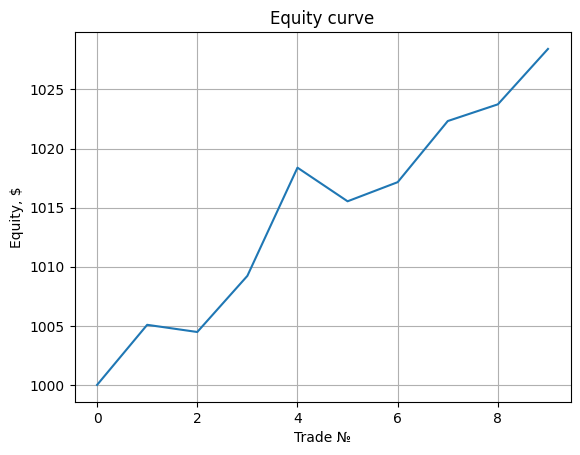

In [17]:
import matplotlib.pyplot as plt

plt.plot(equity_curve)
plt.title("Equity curve")
plt.xlabel("Trade №")
plt.ylabel("Equity, $")
plt.grid()
plt.show()

In [18]:
first = df.iloc[0]
last  = df.iloc[-1]

entry_price = first["start_date_price"]
exit_price  = last["btc_bybit_close_price"]

pnl_abs = exit_price - entry_price
pnl_pct = pnl_abs / entry_price * 100
days    = (last["forecast_start_date"] - first["forecast_start_date"]).days

print(f"Вход : {first['forecast_start_date'].date()}  @ {entry_price:,.2f}")
print(f"Выход: {last['forecast_start_date'].date()}   @ {exit_price:,.2f}")
print(f"Дней удержания: {days} (строк: {len(df)})")
print(f"PnL: {pnl_abs:+,.2f} USD ({pnl_pct:+.2f} %)")

capital = 1000
print(f"$ {capital} -> $ {capital * (1 + pnl_pct/100):,.2f}")

Вход : 2026-01-12  @ 91,004.10
Выход: 2026-04-21   @ 76,331.10
Дней удержания: 99 (строк: 100)
PnL: -14,673.00 USD (-16.12 %)
$ 1000 -> $ 838.77


In [19]:
import numpy as np
import pandas as pd
from itertools import product


def simulate_tp_sl(
    df: pd.DataFrame,
    tp: float = None,
    sl: float = None,
    *,
    tp_long: float = None,
    sl_long: float = None,
    tp_short: float = None,
    sl_short: float = None,
    min_abs_confidence: float = 0.0,
    fee_pct: float = 0.001,
    slippage_pct: float = 0.0001,
    pos_size_pct: float = 1.0,
    double_hit_policy: str = "skip",
    initial_budget: float = 1000.0,
    compounding: bool = True,
) -> dict:
    """
    Симулирует стратегию по предсказаниям с TP / SL (в %), отдельными для LONG и SHORT.

    Симметричный режим:  передать tp/sl  -> используется и для LONG, и для SHORT.
    Асимметричный режим: передать tp_long/sl_long/tp_short/sl_short.
    Любой *_long/*_short, оставшийся None, наследуется от tp/sl.
    """
    if tp_long  is None: tp_long  = tp
    if sl_long  is None: sl_long  = sl
    if tp_short is None: tp_short = tp
    if sl_short is None: sl_short = sl
    if any(x is None for x in (tp_long, sl_long, tp_short, sl_short)):
        raise ValueError("Need either tp+sl or all of tp_long/sl_long/tp_short/sl_short")

    budget = initial_budget
    equity_curve = [budget]
    pnl_list, exit_reasons, sides = [], [], []
    tp_hits = sl_hits = close_hits = skipped_double = 0
    long_tp = long_sl = long_close = 0
    short_tp = short_sl = short_close = 0
    total_fees = total_slip = 0.0

    for _, row in df.iterrows():
        side = row["y_predict"]
        if side not in ("LONG", "SHORT"):
            continue
        conf = row["y_predict_confidence"]
        if pd.isna(conf) or abs(conf) < min_abs_confidence:
            continue

        start = row["start_date_price"]
        close = row["btc_bybit_close_price"]
        vol_hi = row["volatility_in_high_in_percent"]
        vol_lo = row["volatility_in_low_in_percent"]
        if any(pd.isna(x) for x in (start, close, vol_hi, vol_lo)):
            continue

        cur_tp, cur_sl = (tp_long, sl_long) if side == "LONG" else (tp_short, sl_short)

        if side == "LONG":
            hit_sl = vol_lo >= cur_sl
            hit_tp = vol_hi >= cur_tp
        else:
            hit_sl = vol_hi >= cur_sl
            hit_tp = vol_lo >= cur_tp

        if hit_sl and hit_tp:
            if double_hit_policy == "skip":
                skipped_double += 1
                continue
            elif double_hit_policy == "sl":
                pct, reason = -cur_sl, "SL"
            elif double_hit_policy == "tp":
                pct, reason = +cur_tp, "TP"
            else:
                raise ValueError(f"unknown double_hit_policy: {double_hit_policy!r}")
        elif hit_sl:
            pct, reason = -cur_sl, "SL"
        elif hit_tp:
            pct, reason = +cur_tp, "TP"
        else:
            pct = (close / start - 1) * 100 if side == "LONG" else (1 - close / start) * 100
            reason = "CLOSE"

        if reason == "TP":   tp_hits += 1;    long_tp    += (side == "LONG"); short_tp    += (side == "SHORT")
        elif reason == "SL": sl_hits += 1;    long_sl    += (side == "LONG"); short_sl    += (side == "SHORT")
        else:                close_hits += 1; long_close += (side == "LONG"); short_close += (side == "SHORT")

        notional = (budget if compounding else initial_budget) * pos_size_pct
        if notional <= 0:
            break

        exit_ratio = (1 + pct / 100) if side == "LONG" else (1 - pct / 100)
        pnl_gross = notional * (pct / 100)
        entry_fee = notional * fee_pct
        exit_fee  = notional * exit_ratio * fee_pct
        slip      = notional * slippage_pct
        pnl_net   = pnl_gross - entry_fee - exit_fee - slip

        budget += pnl_net
        equity_curve.append(budget)
        total_fees += entry_fee + exit_fee
        total_slip += slip

        pnl_list.append(pct - 2 * fee_pct * 100 - slippage_pct * 100)
        exit_reasons.append(reason)
        sides.append(side)

    n = len(pnl_list)
    base = dict(
        tp_long=tp_long, sl_long=sl_long, tp_short=tp_short, sl_short=sl_short,
        skipped_double=skipped_double,
        final_budget=budget, total_fees=total_fees, total_slippage=total_slip,
        equity_curve=equity_curve,
    )
    if n == 0:
        return {**base,
            "trades": 0, "total_return": 0.0, "avg_return": 0.0,
            "win_rate": 0.0, "sharpe": 0.0, "max_drawdown": 0.0,
            "tp_hits": 0, "sl_hits": 0, "close_exits": 0,
            "long_trades": 0, "long_tp": 0, "long_sl": 0, "long_close": 0, "long_win_rate": 0.0,
            "short_trades": 0, "short_tp": 0, "short_sl": 0, "short_close": 0, "short_win_rate": 0.0,
            "tp_trivial": False,
        }

    pnl = np.array(pnl_list)
    sides_arr = np.array(sides)
    equity_arr = np.array(equity_curve)
    drawdown = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min() * 100
    total_return = (budget / initial_budget - 1) * 100
    sharpe = pnl.mean() / pnl.std() if pnl.std() > 0 else 0.0  # per-trade

    is_long  = sides_arr == "LONG"
    is_short = sides_arr == "SHORT"
    long_n, short_n = int(is_long.sum()), int(is_short.sum())
    long_wr  = float((pnl[is_long]  > 0).mean() * 100) if long_n  else 0.0
    short_wr = float((pnl[is_short] > 0).mean() * 100) if short_n else 0.0

    return {**base,
        "trades": n,
        "total_return": total_return,
        "avg_return": pnl.mean(),
        "win_rate": (pnl > 0).mean() * 100,
        "sharpe": sharpe,
        "max_drawdown": drawdown,
        "tp_hits": tp_hits, "sl_hits": sl_hits, "close_exits": close_hits,
        "long_trades": long_n,  "long_tp": long_tp,   "long_sl": long_sl,   "long_close": long_close,   "long_win_rate": long_wr,
        "short_trades": short_n,"short_tp": short_tp, "short_sl": short_sl, "short_close": short_close, "short_win_rate": short_wr,
        "tp_trivial": (tp_hits == n and n > 0),
    }


def grid_search_one_side(
    df: pd.DataFrame,
    side: str,
    tp_range=(0.5, 5.0, 0.25),
    sl_range=(0.5, 5.0, 0.25),
    *,
    optimize: str = "total_return",
    **sim_kwargs,
) -> pd.DataFrame:
    """
    Грид TP / SL по одной стороне (LONG или SHORT).
    Берёт срез df только с нужной стороной, гридит TP/SL для неё одной,
    оптимизирует по `optimize` (по умолчанию total_return — максимизация дохода).
    """
    assert side in ("LONG", "SHORT"), side
    sub = df[df["y_predict"] == side]

    tp_values = np.round(np.arange(tp_range[0], tp_range[1] + 1e-9, tp_range[2]), 4)
    sl_values = np.round(np.arange(sl_range[0], sl_range[1] + 1e-9, sl_range[2]), 4)

    rows = []
    for tp_v, sl_v in product(tp_values, sl_values):
        if side == "LONG":
            r = simulate_tp_sl(sub, tp_long=tp_v, sl_long=sl_v,
                               tp_short=tp_v, sl_short=sl_v, **sim_kwargs)
            r["tp"], r["sl"] = tp_v, sl_v
        else:
            r = simulate_tp_sl(sub, tp_long=tp_v, sl_long=sl_v,
                               tp_short=tp_v, sl_short=sl_v, **sim_kwargs)
            r["tp"], r["sl"] = tp_v, sl_v
        rows.append(r)

    grid = pd.DataFrame(rows).drop(columns=["equity_curve"], errors="ignore")
    grid = grid.sort_values(
        by=[optimize, "sl_hits", "max_drawdown", "sl"],
        ascending=[False, True, False, True],
    )
    grid = grid.drop_duplicates(subset=["total_return", "win_rate", "tp_hits", "sl_hits"], keep="first")
    return grid.reset_index(drop=True)


In [22]:
TRAIN.columns

Index(['forecast_start_date', 'y_predict', 'y_predict_confidence',
       'start_date_price', 'btc_bybit_close_price', 'btc_bybit_high_price',
       'btc_bybit_low_price', 'y_true', 'price_change',
       'volatility_in_low_in_percent', 'volatility_in_high_in_percent'],
      dtype='object')

In [24]:
SIM_KWARGS = dict(
    min_abs_confidence=0.0,
    fee_pct=0.001,
    slippage_pct=0.0001,
    pos_size_pct=0.2,
    double_hit_policy="skip",
    compounding=True,
)

# 1) ПОДБОР TP/SL ОТДЕЛЬНО ДЛЯ КАЖДОЙ СТОРОНЫ — максимизируем total_return
TP_SL_RANGE = (0.5, 5.0, 0.25)

subset = TRAIN[
    TRAIN['y_predict_confidence'].abs().between(1.0, 1.5)
    & TRAIN['y_true'].notna()
    & TRAIN['y_predict'].notna()
    & (TRAIN['y_predict'] != '')
].copy()


long_grid  = grid_search_one_side(subset, "LONG",  TP_SL_RANGE, TP_SL_RANGE,
                                  optimize="total_return", **SIM_KWARGS)
short_grid = grid_search_one_side(subset, "SHORT", TP_SL_RANGE, TP_SL_RANGE,
                                  optimize="total_return", **SIM_KWARGS)

best_long  = long_grid.iloc[0]
best_short = short_grid.iloc[0]

print("=== TRAIN | LONG-ONLY (TP-сигналы модели) ===")
print(long_grid[["tp", "sl", "trades", "total_return", "win_rate",
                 "tp_hits", "sl_hits", "close_exits", "max_drawdown", "tp_trivial"]].head(10).to_string(index=False))
print(f"\nЛучшая LONG-пара: TP={best_long.tp}%  SL={best_long.sl}%  "
      f"trades={int(best_long.trades)}  return={best_long.total_return:+.2f}%  "
      f"win_rate={best_long.win_rate:.1f}%  DD={best_long.max_drawdown:.2f}%")
if bool(best_long.tp_trivial):
    print("  [WARNING] LONG TP-trivial: SL ни разу не сработал — возможен overfit")

print("\n=== TRAIN | SHORT-ONLY (TN-сигналы модели) ===")
print(short_grid[["tp", "sl", "trades", "total_return", "win_rate",
                  "tp_hits", "sl_hits", "close_exits", "max_drawdown", "tp_trivial"]].head(10).to_string(index=False))
print(f"\nЛучшая SHORT-пара: TP={best_short.tp}%  SL={best_short.sl}%  "
      f"trades={int(best_short.trades)}  return={best_short.total_return:+.2f}%  "
      f"win_rate={best_short.win_rate:.1f}%  DD={best_short.max_drawdown:.2f}%")
if bool(best_short.tp_trivial):
    print("  [WARNING] SHORT TP-trivial: SL ни разу не сработал — возможен overfit")

# 2) КОМБИНИРУЕМ В ЕДИНУЮ СТРАТЕГИЮ И ВАЛИДИРУЕМ НА TEST
print("\n" + "=" * 70)
print(f"COMBINED:  LONG TP/SL = {best_long.tp}/{best_long.sl}  |  "
      f"SHORT TP/SL = {best_short.tp}/{best_short.sl}")
print("=" * 70)

train_combined = simulate_tp_sl(
    TRAIN,
    tp_long=best_long.tp,   sl_long=best_long.sl,
    tp_short=best_short.tp, sl_short=best_short.sl,
    **SIM_KWARGS,
)
test_combined = simulate_tp_sl(
    TEST,
    tp_long=best_long.tp,   sl_long=best_long.sl,
    tp_short=best_short.tp, sl_short=best_short.sl,
    **SIM_KWARGS,
)

def _print_summary(name, r):
    print(f"\n--- {name} ---")
    print(f"  trades       = {r['trades']}  (LONG {r['long_trades']} / SHORT {r['short_trades']})")
    print(f"  total_return = {r['total_return']:+.2f}%   final ${r['final_budget']:.2f}  (start $1000)")
    print(f"  win_rate     = {r['win_rate']:.1f}%  "
          f"(LONG {r['long_win_rate']:.1f}% | SHORT {r['short_win_rate']:.1f}%)")
    print(f"  exits        = TP {r['tp_hits']} / SL {r['sl_hits']} / CLOSE {r['close_exits']}  "
          f"skipped_double={r['skipped_double']}")
    print(f"  LONG  exits  = TP {r['long_tp']} / SL {r['long_sl']} / CLOSE {r['long_close']}")
    print(f"  SHORT exits  = TP {r['short_tp']} / SL {r['short_sl']} / CLOSE {r['short_close']}")
    print(f"  sharpe (per-trade) = {r['sharpe']:.3f}   max DD = {r['max_drawdown']:.2f}%")
    print(f"  fees=${r['total_fees']:.2f}  slip=${r['total_slippage']:.2f}")

_print_summary("TRAIN (combined per-side)", train_combined)
_print_summary("TEST  (combined per-side)", test_combined)


=== TRAIN | LONG-ONLY (TP-сигналы модели) ===
  tp   sl  trades  total_return  win_rate  tp_hits  sl_hits  close_exits  max_drawdown  tp_trivial
4.75 1.50      20      4.224897      65.0        5        5           10     -1.038935       False
4.50 1.50      20      3.967190      65.0        5        5           10     -1.038935       False
4.75 1.75      20      3.963964      65.0        5        5           10     -1.187662       False
4.75 3.00      20      3.874680      65.0        5        2           13     -1.612262       False
4.75 2.00      20      3.829759      65.0        5        4           11     -1.216169       False
4.75 2.25      20      3.818359      65.0        5        3           12     -1.315266       False
4.75 3.25      20      3.770265      65.0        5        2           13     -1.711161       False
4.75 3.75      20      3.745702      65.0        5        1           14     -1.734426       False
4.25 1.50      20      3.709994      65.0        5        5    

In [25]:
print("Распределение total_return по уровню TP (медиана по SL) — LONG:")
print(long_grid.groupby("tp")[["total_return", "win_rate"]].median().round(3).to_string())

print("\nРаспределение total_return по уровню TP (медиана по SL) — SHORT:")
print(short_grid.groupby("tp")[["total_return", "win_rate"]].median().round(3).to_string())


Распределение total_return по уровню TP (медиана по SL) — LONG:
      total_return  win_rate
tp                          
0.50        -0.873    73.684
0.75        -0.584    70.000
1.00        -0.144    70.000
1.25         0.452    70.000
1.50         0.958    70.000
1.75         0.608    65.000
2.00         0.729    65.000
2.25         1.131    65.000
2.50         1.534    65.000
2.75         1.708    65.000
3.00         1.879    65.000
3.25         2.132    65.000
3.50         2.386    65.000
3.75         2.640    65.000
4.00         2.895    65.000
4.25         3.150    65.000
4.50         3.406    65.000
4.75         3.662    65.000
5.00         2.442    65.000

Распределение total_return по уровню TP (медиана по SL) — SHORT:
      total_return  win_rate
tp                          
0.50         0.064    84.615
0.75         0.694    84.615
1.00         1.249    84.615
1.25         1.113    78.571
1.50         1.658    78.571
1.75         2.166    78.571
2.00         2.677    78.571
